<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week4/Day2/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Régression logistique pour la prédiction des admissions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Charger le dataset
url = "https://raw.githubusercontent.com/kaleko/CourseraML/master/ex2/data/ex2data1.txt"
df = pd.read_csv(url, header=None, names=['exam1', 'exam2', 'admitted'])

print(df.shape)
display(df.head())
print(df['admitted'].value_counts())

(100, 3)


,exam1,exam2,admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


admitted
1    60
0    40
Name: count, dtype: int64


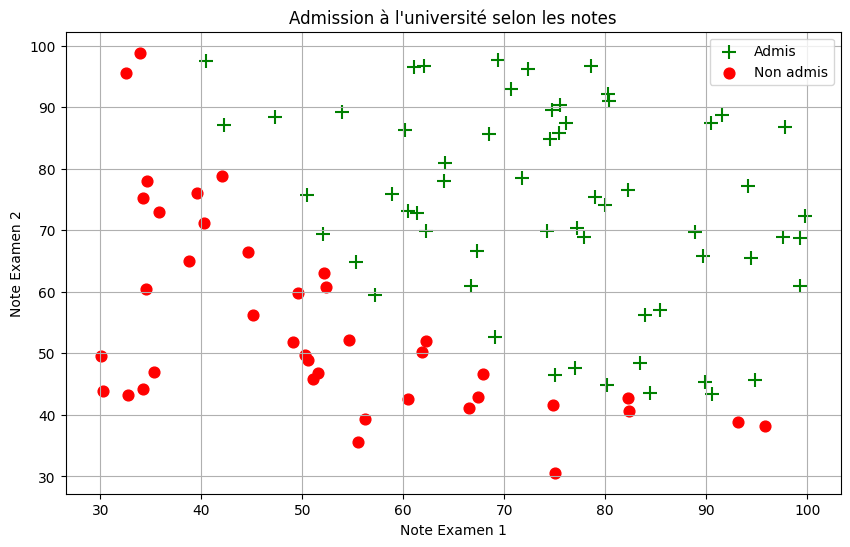

In [2]:
# Visualisation
plt.figure(figsize=(10, 6))

admitted = df[df['admitted'] == 1]
rejected = df[df['admitted'] == 0]

plt.scatter(admitted['exam1'], admitted['exam2'],
            color='green', marker='+', s=100, label='Admis')
plt.scatter(rejected['exam1'], rejected['exam2'],
            color='red', marker='o', s=60, label='Non admis')

plt.xlabel('Note Examen 1')
plt.ylabel('Note Examen 2')
plt.title('Admission à l\'université selon les notes')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# Préparer les données
X = df[['exam1', 'exam2']]
y = df['admitted']

# Entraîner la Régression Logistique
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X, y)

print(" Modèle entraîné !")
print(f"Coefficients : {model.coef_}")
print(f"Intercept    : {model.intercept_}")

 Modèle entraîné !
Coefficients : [[0.20535491 0.2005838 ]]
Intercept    : [-25.05219314]


In [6]:
# Faire des prédictions
y_pred = model.predict(X)

# Accuracy
acc = accuracy_score(y, y_pred)
print(f"Accuracy : {acc:.4f}")

# Rapport complet
print("\n=== Rapport de classification ===")
print(classification_report(y, y_pred,
      target_names=['Non admis', 'Admis']))

# Prédiction pour un nouvel étudiant
etudiant = [[45, 85]]
prediction = model.predict(etudiant)
probabilite = model.predict_proba(etudiant)

print(f"\n=== Prédiction nouvel étudiant ===")
print(f"Notes : Exam1=45, Exam2=85")
print(f"Résultat : {'Admis ' if prediction[0] == 1 else 'Non admis '}")
print(f"Probabilité d'admission : {probabilite[0][1]:.2%}")

Accuracy : 0.8900

=== Rapport de classification ===
              precision    recall  f1-score   support

   Non admis       0.87      0.85      0.86        40
       Admis       0.90      0.92      0.91        60

    accuracy                           0.89       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100


=== Prédiction nouvel étudiant ===
Notes : Exam1=45, Exam2=85
Résultat : Admis 
Probabilité d'admission : 77.53%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


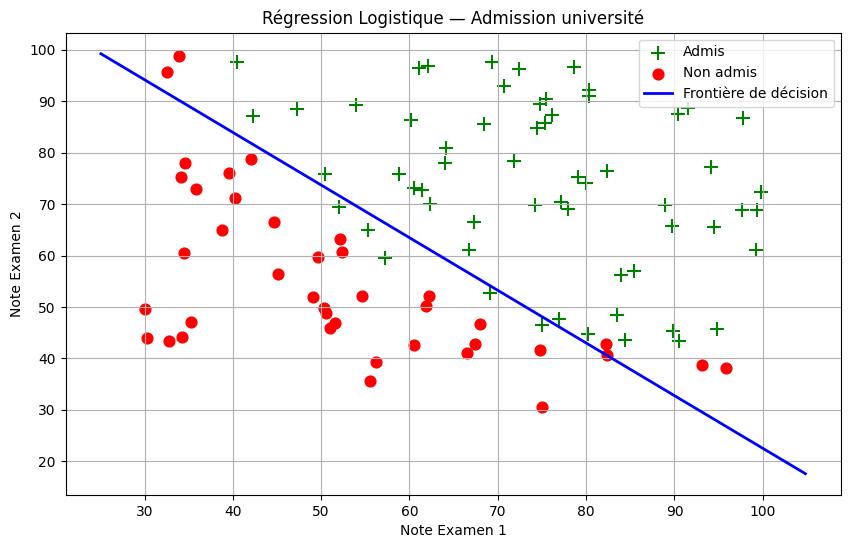

In [7]:
# Visualisation avec frontière de décision
plt.figure(figsize=(10, 6))

# Points
plt.scatter(admitted['exam1'], admitted['exam2'],
            color='green', marker='+', s=100, label='Admis')
plt.scatter(rejected['exam1'], rejected['exam2'],
            color='red', marker='o', s=60, label='Non admis')

# Frontière de décision
x_min, x_max = df['exam1'].min()-5, df['exam1'].max()+5
xx = np.linspace(x_min, x_max, 300)
yy = -(model.coef_[0][0] * xx + model.intercept_[0]) / model.coef_[0][1]

plt.plot(xx, yy, color='blue', linewidth=2, label='Frontière de décision')

plt.xlabel('Note Examen 1')
plt.ylabel('Note Examen 2')
plt.title('Régression Logistique — Admission université')
plt.legend()
plt.grid(True)
plt.show()

## Défi : Régression Logistique — Admission Université

### Résultats du modèle

| Métrique | Valeur |
|---|---|
| Accuracy | 0.89 |
| Precision (Admis) | 0.90 |
| Recall (Admis) | 0.92 |
| F1-Score (Admis) | 0.91 |

### Interprétation

**Coefficients :**
- Exam1 : 0.205 → chaque point supplémentaire augmente
  légèrement la probabilité d'admission
- Exam2 : 0.200 → même effet pour l'examen 2
- Intercept : -25.05 → seuil de base du modèle

**Accuracy 89% :**
- Le modèle prédit correctement 89 étudiants sur 100
- Très bon résultat pour un modèle simple !

**Prédiction exemple :**
- Exam1=45, Exam2=85 → Admis avec 77.53% de probabilité

**Frontière de décision :**
- La ligne bleue sépare les admis des non-admis
- Les étudiants au-dessus de la ligne → Admis
- Les étudiants en dessous → Non admis

### Conclusion
La Régression Logistique est efficace pour ce problème
de classification binaire. Les deux examens ont un impact
similaire sur l'admission.